In [1]:
import pandas as pd
from rdkit import Chem
from benchmarking.metrics.base_metrics import (
    load_all_feature_tables,
)

from benchmarking.constants import INCHIKEY_COLUMN, SCORE_COLUMN
from functools import lru_cache
from rdkit.Chem import AllChem, DataStructs
from tqdm import tqdm
from urllib.error import HTTPError, URLError
from urllib.request import urlopen
from tqdm import tqdm
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import RDLogger

# Disable all logging
RDLogger.DisableLog("rdApp.*")
pd.set_option("mode.chained_assignment", None)  # Disable SettingWithCopyWarning

In [2]:
ground_truth_library_data = pd.read_parquet(
    "../data/library_spectra/reframe_spikein_lib.pq"
)
ground_truth_library_data["inchikey14"] = ground_truth_library_data[
    "inchikey_2d"
].apply(lambda x: x.split("-")[0])
ground_truth_library_data.head(2)

,normalized_mzs,normalized_intensities,precursor_mz,inchikey_2d,ingest_lib,num_filtered_peaks,inchikey14
2563,"[43.735428, 60.039295, 90.405807, 212.208878, ...","[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11....",180.102,CPJSUEIXXCENMM-UHFFFAOYSA-N,reframe_spikein_lib,0,CPJSUEIXXCENMM
707,"[44.014629, 69.070305, 70.064568, 77.037712, 7...","[127.26162, 105.502022, 121.080711, 177.361496...",233.129,ROBVIMPUHSLWNV-UHFFFAOYSA-N,reframe_spikein_lib,0,ROBVIMPUHSLWNV


In [3]:
smiles_mapper_df = pd.read_csv(
    "../data/library_spectra/reframe_smiles_list.csv",
    usecols=["canonical_ikey", "smile"],
)

smiles_mapper_dict = smiles_mapper_df.set_index("canonical_ikey")["smile"].to_dict()

In [4]:
smiles_mapper_df["inchikey14"] = smiles_mapper_df["canonical_ikey"].apply(
    lambda x: x.split("-")[0]
)
smiles_mapper_df["inchikey14"].nunique(), smiles_mapper_df["canonical_ikey"].nunique()

(11856, 12317)

In [5]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/MSV000098263"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


## Calculating the tanimoto similarity for false positive annotations

In [6]:
true_inchikeys = set(ground_truth_library_data["inchikey14"].to_list())
gt_df = ground_truth_library_data[["inchikey14", "inchikey_2d"]].drop_duplicates()

In [7]:
@lru_cache(maxsize=50000)
def query_pubchem_smiles(inchikey: str):
    if not inchikey:
        return None

    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/"
        f"{inchikey}/property/CanonicalSMILES/TXT"
    )

    try:
        with urlopen(url, timeout=8) as resp:
            text = resp.read().decode("utf-8").strip()
            return text if text else None
    except (HTTPError, URLError, TimeoutError, ValueError):
        return None


def get_smiles_from_inchikey(full_inchikey: str | None = None):
    # 1) Try local mapping by full InChIKey.
    hit = smiles_mapper_dict.get(full_inchikey)
    if isinstance(hit, str) and hit:
        return hit

    # 3) Fall back to PubChem query (prefer full key if available).
    pubchem_hit = query_pubchem_smiles(full_inchikey)
    if pubchem_hit:
        return pubchem_hit

    return None


generator = rdFingerprintGenerator.GetMorganGenerator()

sim_dict = {}
for tool, df in merged_feature_tables.items():
    df = df[df[SCORE_COLUMN].notna()]

    if tool not in sim_dict:
        sim_dict[tool] = []

    predicted_full_inchikeys = df[df[SCORE_COLUMN] >= 0.7].dropna(
        subset=[INCHIKEY_COLUMN]
    )
    predicted_full_inchikeys["inchikey14"] = predicted_full_inchikeys[
        INCHIKEY_COLUMN
    ].apply(lambda x: x.split("-")[0])

    unique_false_positives_14 = set(predicted_full_inchikeys["inchikey14"]).difference(
        true_inchikeys
    )

    print(f"Tool: {tool}, Unique False Positives: {len(unique_false_positives_14)}")

    fps = predicted_full_inchikeys[
        predicted_full_inchikeys["inchikey14"].isin(unique_false_positives_14)
    ]
    fps.drop_duplicates(subset=["inchikey14"], inplace=True)

    # Build pairwise true/false-positive similarities.
    for fp_inchikey in tqdm(fps[INCHIKEY_COLUMN], desc=f"Processing {tool}"):
        fp_smiles = get_smiles_from_inchikey(fp_inchikey)
        if not fp_smiles:
            continue

        mol1 = Chem.MolFromSmiles(fp_smiles)
        if mol1 is None:
            continue

        all_tp_mols = []

        for tp_inchikey in gt_df["inchikey_2d"].to_list():
            tp_smiles = get_smiles_from_inchikey(tp_inchikey)
            if not tp_smiles:
                continue

            mol2 = Chem.MolFromSmiles(tp_smiles)
            if mol2 is None:
                continue
            all_tp_mols.append(mol2)

        # Generate Morgan fingerprints for both molecules.
        fp_fp = generator.GetFingerprint(mol1)
        tp_fps = [generator.GetFingerprint(mol2) for mol2 in all_tp_mols]
        scores = DataStructs.BulkTanimotoSimilarity(fp_fp, tp_fps)
        if scores:
            top_score = max(scores)

        sim_dict[tool].append(round(top_score, 3))

Tool: metaboscape, Unique False Positives: 861


Processing metaboscape: 100%|██████████| 861/861 [23:52<00:00,  1.66s/it]   


Tool: msdial, Unique False Positives: 586


Processing msdial: 100%|██████████| 586/586 [06:32<00:00,  1.49it/s]


Tool: mzmine, Unique False Positives: 1208


Processing mzmine: 100%|██████████| 1208/1208 [13:01<00:00,  1.55it/s]


## Plotting the similarity distribution across tools

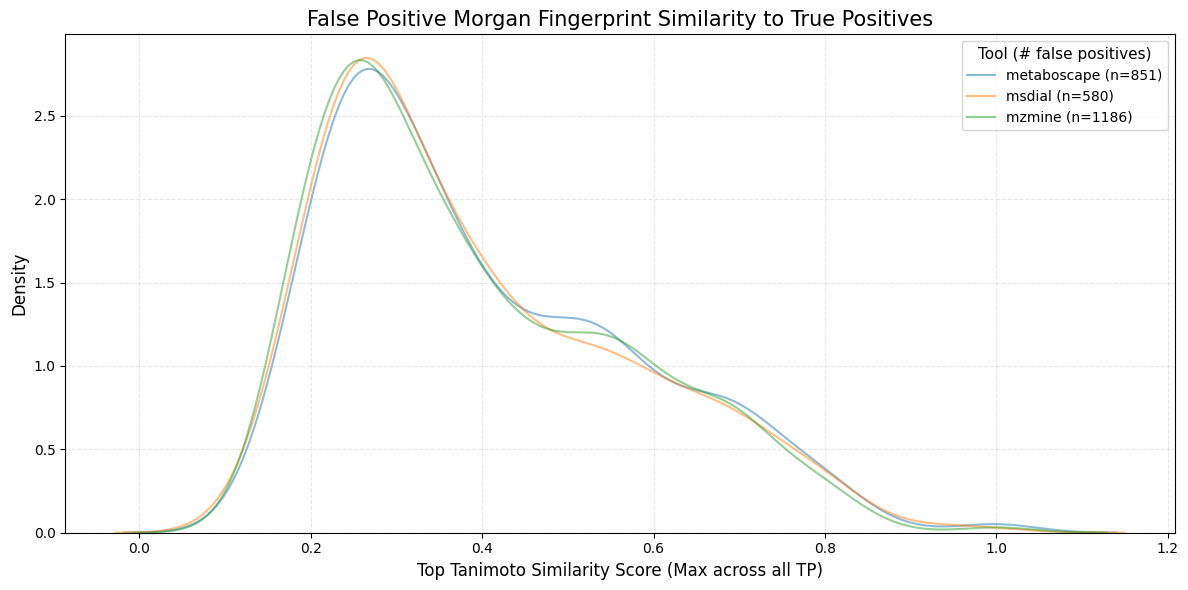

In [8]:
# Distribution of top Tanimoto scores for false positives across tools
plt.figure(figsize=(12, 6))
for tool, scores in sim_dict.items():
    sns.kdeplot(
        scores,
        label=f"{tool} (n={len(scores)})",
        fill=False,
        alpha=0.5,
    )

plt.title(
    "False Positive Morgan Fingerprint Similarity to True Positives",
    fontsize=15,
)
plt.xlabel("Top Tanimoto Similarity Score (Max across all TP)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Tool (# false positives)", fontsize=10, title_fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("../figures/false_positive_tanimoto_similarity.png", dpi=300)
plt.show()